<a href="https://colab.research.google.com/github/SrishtiKaranth/EV-Charging-Station-Analysis-with-PySpark/blob/main/EV_Charging_station_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EV Charging Station Analysis with PySpark

**Data Source:**  
[NREL Alternative Fuel Stations API](https://developer.nrel.gov/docs/transportation/alt-fuel-stations-v1/) — an official dataset from the **U.S. Department of Energy** providing nationwide information on electric vehicle (EV) charging infrastructure.

---

## Workflow

### 1. Data Ingestion
Retrieve EV charging station data programmatically from the **NREL REST API**.

### 2. Data Processing with PySpark
Load and inspect the dataset using **Spark DataFrames** and analyze the schema.

### 3. Data Cleaning & Feature Engineering
Handle missing values, normalize data types, and derive new analytical features.

### 4. Analytical Queries
Use **Spark SQL** to analyze infrastructure distribution, network providers, and charging capabilities.

### 5. Visualization & Insights
Generate charts using Python visualization libraries to highlight key trends in EV charging infrastructure.

---

## Technologies Used

- **PySpark** - distributed data processing  
- **Spark SQL** - analytical querying  
- **Python Requests** - API data ingestion  
- **Matplotlib** - visualization  
- **REST APIs** - real-world data source  

---

## 0. Setup

In [23]:
# Uncomment if running locally
# !pip install pyspark requests

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import requests
import pandas as pd
import matplotlib.pyplot as plt

spark = SparkSession.builder \
    .appName("EV Station Analysis") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print("Spark version:", spark.version)

Spark version: 4.0.2


## 1. Fetch Real Data from NREL API

The NREL (US Dept of Energy) Alternative Fuels Station API provides real data on every registered EV charging station in the US. `DEMO_KEY` allows up to 100 requests/day with no registration.

In [24]:
import requests

API_KEY = "RX6y79LJ0JQ11prpzr12OrEgnwj8Cm4zBztvJbvO"
BASE_URL = "https://developer.nrel.gov/api/alt-fuel-stations/v1.json"

all_stations = []
page = 1
limit = 200
max_rows = 1000

while True:
    params = {
        "api_key": API_KEY,
        "fuel_type": "ELEC",
        "country": "US",
        "limit": limit,
        "offset": (page - 1) * limit,
    }

    resp = requests.get(BASE_URL, params=params, timeout=30)
    resp.raise_for_status()

    data = resp.json()
    stations = data.get("fuel_stations", [])

    if not stations:
        break

    all_stations.extend(stations)
    print(f"stations (total: {len(all_stations)})")

    # avoiding rate limits
    if len(all_stations) >= max_rows:
        all_stations = all_stations[:max_rows]
        break

    if len(stations) < limit:
        break

    page += 1

print(f"\nTotal stations: {len(all_stations)}")

stations (total: 200)
stations (total: 400)
stations (total: 600)
stations (total: 800)
stations (total: 1000)

Total stations: 1000


## 2. Load into PySpark

In [25]:
# flatten JSON to Pandas to Spark
pdf = pd.json_normalize(all_stations)

# using the required columns
columns_required = [
    "id", "station_name", "city", "state", "zip",
    "ev_network", "access_code", "open_date",
    "ev_level1_evse_num", "ev_level2_evse_num", "ev_dc_fast_num",
    "ev_connector_types", "latitude", "longitude"
]
cols = [c for c in columns_required if c in pdf.columns]
pdf = pdf[cols]

df = spark.createDataFrame(pdf)
print(f"Rows: {df.count():,}  |  Columns: {len(df.columns)}")
df.printSchema()

Rows: 1,000  |  Columns: 14
root
 |-- id: long (nullable = true)
 |-- station_name: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- zip: string (nullable = true)
 |-- ev_network: string (nullable = true)
 |-- access_code: string (nullable = true)
 |-- open_date: string (nullable = true)
 |-- ev_level1_evse_num: double (nullable = true)
 |-- ev_level2_evse_num: double (nullable = true)
 |-- ev_dc_fast_num: double (nullable = true)
 |-- ev_connector_types: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)



In [26]:
df.show(5, truncate=True)

+----+--------------------+-----------+-----+-----+--------------+-----------+----------+------------------+------------------+--------------+--------------------+----------------+-----------------+
|  id|        station_name|       city|state|  zip|    ev_network|access_code| open_date|ev_level1_evse_num|ev_level2_evse_num|ev_dc_fast_num|  ev_connector_types|        latitude|        longitude|
+----+--------------------+-----------+-----+-----+--------------+-----------+----------+------------------+------------------+--------------+--------------------+----------------+-----------------+
|1517|LADWP - Truesdale...| Sun Valley|   CA|91352|SHELL_RECHARGE|    private|1999-10-15|               NaN|              57.0|           2.0|[CHADEMO, J1772, ...|34.2483191527193|-118.387971374343|
|1523|Los Angeles Conve...|Los Angeles|   CA|90015| Non-Networked|     public|1995-08-30|               NaN|               8.0|           NaN|             [J1772]|       34.040539|      -118.271387|
|1525

## 3. Clean & Transform

In [27]:
from pyspark.sql import functions as F

# cast EV port columns to int:
# if null -> 0
# NaN / invalid values -> NULL via try_cast -> 0 via coalesce
df = (
    df
    .withColumn(
        "l1_ports",
        F.coalesce(F.expr("try_cast(ev_level1_evse_num as int)"), F.lit(0))
    )
    .withColumn(
        "l2_ports",
        F.coalesce(F.expr("try_cast(ev_level2_evse_num as int)"), F.lit(0))
    )
    .withColumn(
        "dcfc_ports",
        F.coalesce(F.expr("try_cast(ev_dc_fast_num as int)"), F.lit(0))
    )
    .withColumn(
        "total_ports",
        F.col("l1_ports") + F.col("l2_ports") + F.col("dcfc_ports")
    )
    .withColumn(
        "has_dcfc",
        F.when(F.col("dcfc_ports") > 0, F.lit("Yes")).otherwise(F.lit("No"))
    )
    .withColumn(
        "open_year",
        F.year(F.to_date(F.col("open_date"), "yyyy-MM-dd"))
    )
)

df.select(
    "station_name",
    "state",
    "ev_network",
    "l1_ports",
    "l2_ports",
    "dcfc_ports",
    "total_ports",
    "has_dcfc",
    "open_year"
).show(10, truncate=False)

+---------------------------------+-----+--------------+--------+--------+----------+-----------+--------+---------+
|station_name                     |state|ev_network    |l1_ports|l2_ports|dcfc_ports|total_ports|has_dcfc|open_year|
+---------------------------------+-----+--------------+--------+--------+----------+-----------+--------+---------+
|LADWP - Truesdale Center         |CA   |SHELL_RECHARGE|0       |57      |2         |59         |Yes     |1999     |
|Los Angeles Convention Center    |CA   |Non-Networked |0       |8       |0         |8          |No      |1995     |
|LADWP - John Ferraro Building    |CA   |Non-Networked |0       |379     |15        |394        |Yes     |1999     |
|LADWP - Haynes Power Plant       |CA   |Non-Networked |0       |31      |0         |31         |No      |2018     |
|LADWP - Harbor Generating Station|CA   |Non-Networked |0       |12      |0         |12         |No      |1999     |
|LADWP - Sylmar West              |CA   |Non-Networked |0       

## 4. Aggregations with DataFrame API

In [28]:
# Stations and ports by state
df.groupBy("state") \
  .agg(
      F.count("*").alias("stations"),
      F.sum("total_ports").alias("total_ports"),
      F.sum("dcfc_ports").alias("dcfc_ports"),
      F.round(F.avg("total_ports"), 1).alias("avg_ports_per_station")
  ) \
  .orderBy(F.desc("stations")) \
  .show(15)

+-----+--------+-----------+----------+---------------------+
|state|stations|total_ports|dcfc_ports|avg_ports_per_station|
+-----+--------+-----------+----------+---------------------+
|   CA|     505|       6240|       130|                 12.4|
|   TX|     100|        195|        60|                  2.0|
|   SC|      90|        240|         5|                  2.7|
|   OR|      50|        315|         0|                  6.3|
|   WA|      50|        460|         0|                  9.2|
|   WI|      25|         40|         0|                  1.6|
|   CT|      25|         90|         0|                  3.6|
|   NY|      20|         75|         0|                  3.8|
|   IL|      15|         45|         0|                  3.0|
|   VA|      10|         25|         5|                  2.5|
|   NC|      10|         15|         0|                  1.5|
|   VT|      10|         40|         0|                  4.0|
|   MO|      10|         15|         0|                  1.5|
|   IA| 

In [29]:
# Charging network breakdown
df.groupBy("ev_network") \
  .agg(
      F.count("*").alias("stations"),
      F.sum("dcfc_ports").alias("dcfc_ports")
  ) \
  .orderBy(F.desc("stations")) \
  .show(10)

+-------------------+--------+----------+
|         ev_network|stations|dcfc_ports|
+-------------------+--------+----------+
|      Non-Networked|     890|       195|
|ChargePoint Network|      90|         0|
|          POWERFLEX|      10|         0|
|     SHELL_RECHARGE|       5|        10|
|        ENVIROSPARK|       5|         0|
+-------------------+--------+----------+



In [30]:
# Year-over-year station openings (growth trend)
df.filter(F.col("open_year").isNotNull()) \
  .groupBy("open_year") \
  .count() \
  .orderBy("open_year") \
  .show(20)

+---------+-----+
|open_year|count|
+---------+-----+
|     1995|    5|
|     1997|   25|
|     1998|   50|
|     1999|   40|
|     2000|   10|
|     2002|   70|
|     2004|   75|
|     2005|   10|
|     2006|   10|
|     2008|   55|
|     2009|   40|
|     2010|  140|
|     2011|  255|
|     2012|   65|
|     2013|   15|
|     2014|   20|
|     2015|   20|
|     2016|   30|
|     2017|   20|
|     2018|    5|
+---------+-----+
only showing top 20 rows


## 5. Spark SQL Queries

In [31]:
df.createOrReplaceTempView("ev_stations")

In [32]:
# top 10 states by DC fast charging port count
spark.sql("""
    SELECT
        state,
        COUNT(*) AS stations,
        SUM(dcfc_ports) AS total_dcfc_ports,
        ROUND(SUM(dcfc_ports) / NULLIF(COUNT(*), 0), 2) AS avg_dcfc_per_station
    FROM ev_stations
    WHERE state IS NOT NULL
    GROUP BY state
    HAVING SUM(dcfc_ports) > 0
    ORDER BY total_dcfc_ports DESC
    LIMIT 10
""").show()

+-----+--------+----------------+--------------------+
|state|stations|total_dcfc_ports|avg_dcfc_per_station|
+-----+--------+----------------+--------------------+
|   CA|     505|             130|                0.26|
|   TX|     100|              60|                 0.6|
|   SC|      90|               5|                0.06|
|   VA|      10|               5|                 0.5|
|   CO|       5|               5|                 1.0|
+-----+--------+----------------+--------------------+



In [33]:
# network market share using a window function
spark.sql("""
    SELECT
        ev_network,
        COUNT(*) AS stations,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1) AS market_share_pct
    FROM ev_stations
    WHERE ev_network IS NOT NULL
    GROUP BY ev_network
    ORDER BY stations DESC
    LIMIT 10
""").show()

+-------------------+--------+----------------+
|         ev_network|stations|market_share_pct|
+-------------------+--------+----------------+
|      Non-Networked|     890|            89.0|
|ChargePoint Network|      90|             9.0|
|          POWERFLEX|      10|             1.0|
|     SHELL_RECHARGE|       5|             0.5|
|        ENVIROSPARK|       5|             0.5|
+-------------------+--------+----------------+



In [34]:
# many stations but low DCFC ratio
spark.sql("""
    SELECT
        state,
        COUNT(*) AS stations,
        SUM(dcfc_ports) AS dcfc_ports,
        ROUND(SUM(dcfc_ports) * 100.0 / NULLIF(SUM(total_ports), 0), 1) AS dcfc_coverage_pct
    FROM ev_stations
    GROUP BY state
    HAVING COUNT(*) >= 20
    ORDER BY dcfc_coverage_pct ASC
    LIMIT 10
""").show()

+-----+--------+----------+-----------------+
|state|stations|dcfc_ports|dcfc_coverage_pct|
+-----+--------+----------+-----------------+
|   OR|      50|         0|              0.0|
|   WI|      25|         0|              0.0|
|   CT|      25|         0|              0.0|
|   WA|      50|         0|              0.0|
|   NY|      20|         0|              0.0|
|   SC|      90|         5|              2.1|
|   CA|     505|       130|              2.1|
|   TX|     100|        60|             30.8|
+-----+--------+----------+-----------------+



## 6. Visualisations

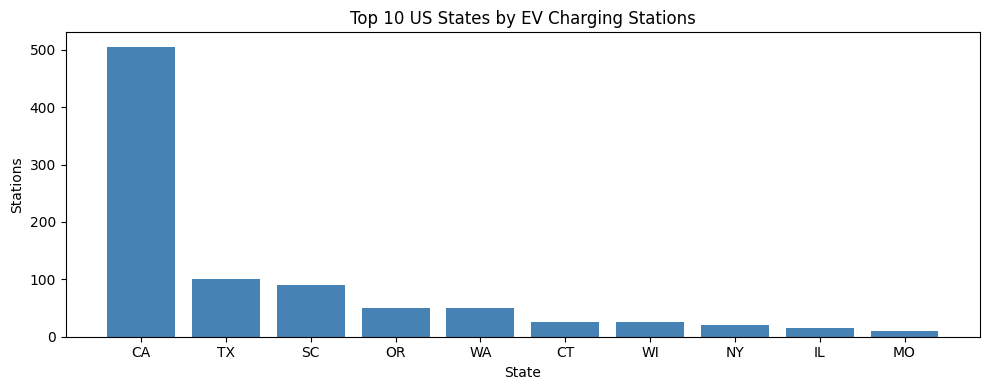

In [35]:
# top 10 states by station count
top_states = df.groupBy("state") \
    .agg(F.count("*").alias("stations")) \
    .orderBy(F.desc("stations")).limit(10).toPandas()

plt.figure(figsize=(10, 4))
plt.bar(top_states["state"], top_states["stations"], color="steelblue")
plt.title("Top 10 US States by EV Charging Stations")
plt.xlabel("State")
plt.ylabel("Stations")
plt.tight_layout()
plt.show()

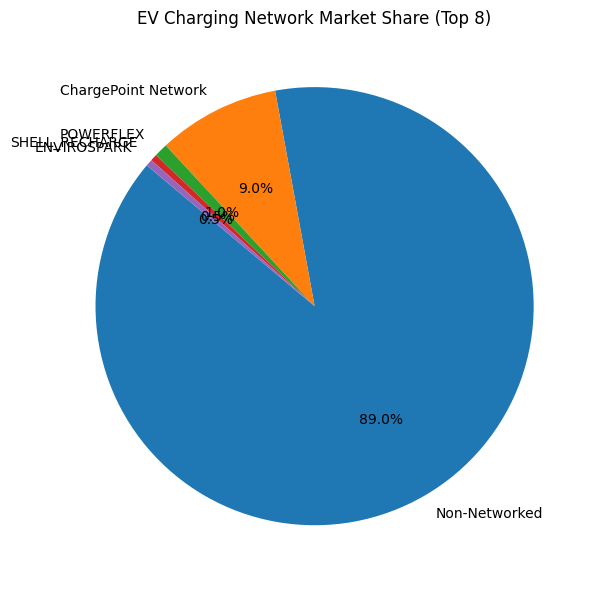

In [36]:
# network market share pie chart
net = df.groupBy("ev_network").count() \
    .orderBy(F.desc("count")).limit(8).toPandas()
net["ev_network"] = net["ev_network"].fillna("Unknown")

plt.figure(figsize=(8, 6))
plt.pie(net["count"], labels=net["ev_network"], autopct="%1.1f%%", startangle=140)
plt.title("EV Charging Network Market Share (Top 8)")
plt.tight_layout()
plt.show()

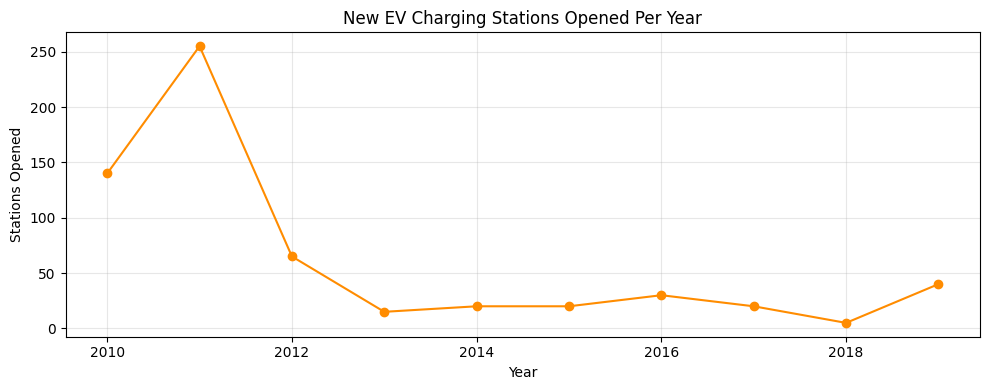

In [37]:
# station opening trend by year
growth = df.filter(F.col("open_year").between(2010, 2024)) \
    .groupBy("open_year").count() \
    .orderBy("open_year").toPandas()

plt.figure(figsize=(10, 4))
plt.plot(growth["open_year"], growth["count"], marker="o", color="darkorange")
plt.title("New EV Charging Stations Opened Per Year")
plt.xlabel("Year")
plt.ylabel("Stations Opened")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Key Takeaways

| Insight | Finding |
|---|---|
| Geographic concentration | California leads with significantly more stations than any other state |
| DC fast charging gap | Most stations are Level 2 — DCFC rollout is the growth frontier for operators |
| Network fragmentation | The market is split across many networks — interoperability (OCPI protocol) is critical |
| Rapid growth | Station openings have accelerated dramatically since 2018 |
| Underserved markets | Several high-station-count states still have low DCFC ratios — expansion opportunity |

---

In [38]:
spark.stop()